### Neural alignment to behavior
- feeder rasters separated by open/closed, sorted by feeder ID and interaction duration
- feeder tuning curves warped to span ~1 sec(?) before start to ~1 sec after end, split by feeder/state
    - or whisker plot avg firing before, during, after split by feeder/state w/ dashed line for baseline FR?
- place map?
- eating raster sorted by duration
- eating tuning curve warped to span ~1 sec(?) before start to ~1 sec after end
    - or whisker plot avg firing before, during, after w/ dashed line for baseline FR?
- cache raster sorted by duration
- retrieve raster sorted by duration

In [ ]:
''' feeder responses
250328 (128 total cells, ~23% feeder responsive):
    18 up during: 15, 36, 51, 63, 92, 213, 244, 257, 258, 298, 314, 318, 405, 409, 442, 470, 541, 543
    7 up after: 37, 134, 192, 218, 425, 462, 491
    4 other: 399, 456, 478, 525    
    cell 134 is a projection cell
    
    all
        during: 213
        after: 
    yellow
        during: (15, 298, 442) 36, 244, 258, 314, 405, 543
        after: 134, 491
    green
        during: 
        after: 
    red
        during: (15, 51, 244, 405, 442), 92, 257, 318, 470, 541
        after: (298), 192
    blue
        during: 63, 409
        after: 37, 218, 425, 462
    
250326 (64 total cells, ~28% feeder responsive):
    12 up during: 2, 14, 137, 144, 255, 304, 350, 353, 358, 362, 392, 408
    3 up after: 71, 356, 360
    3 other (off during? on before/during/after? other things?): 1, 164, 322
    cells 71, 255 are projection cells
    
    all
        during: 14, 255
        after: 
    yellow
        during: 350, 392
        after: 71, 356
    green
        during: 2, 137, 362
        after: 360
    red
        during: (2), 304, (350), 
        after
    blue
        during: 144, 353
        after
'''

In [8]:
feeder_responsive_idx = []

ex_cells = np.asarray([36, 244, 258, 314, 405, 543])
for cell_id in ex_cells:
    c_idx = np.where(good_clusters==cell_id)[0][0]
    feeder_responsive_idx.append(c_idx)
print(feeder_responsive_idx)

[7, 43, 48, 57, 82, 122]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.cm import get_cmap

from scipy import stats
from scipy.ndimage import gaussian_filter, gaussian_filter1d

import sys
sys.path.append("..//neural/")
import format_waveform_data, waveform_analysis
sys.path.append("..//utils/")
from load_matlab_data import loadmat_sbx

import scipy.io
import os
import mat73
from scipy.io import loadmat, savemat

In [9]:
''' set paths '''
root_dir = "Z:/Isabel/data/"
bird_id = 'SLV132'
session_id = '250326'
locker_root = f"{root_dir}hpc_implants/{bird_id}/{bird_id}_{session_id}/"
local_root = "../data/antidromic_stim/"

# to load waveforms and probe info
ephys_id = "SLV132_250326_100125" # "SLV132_250328_104521"
ks_dir = "kilosort4_blanked/"
# session_dir = f"{locker_root}/{ephys_id}/" # locker
session_dir = f"{local_root}{bird_id}/{bird_id}_{session_id}/" # local
ephys_dir = f"{session_dir}raw_ephys_output/"

'''
specify broken channels for this session
----------------------------------------
SLV132_250326 - np.asarray([40, 46, 53, 56, 63])
SLV132_250328 - np.asarray([53, 56, 63])
'''
broken_channels = np.asarray([40, 46, 53, 56, 63])

# to load raw keypoints, model performance measures, behavior
pred_file = f'250407_posture_2stage_face.npy' # f'250402_posture_2stage_face.npy'
data_dir = f"{locker_root}behavior_data/"
pred_path = f"{data_dir}{pred_file}"
annotated_seed_file = "annotatedSeeds.mat"
# annotated_seed_file = "annotatedSeeds_errors.mat"

# feeder times (minutes)
# 250328
# feeder_open = np.asarray([10, 55, 110])
# feeder_close = np.asarray([22, 65, 117])
# 250326
feeder_open = np.asarray([10, 60, 112])
feeder_close = np.asarray([20, 72, 122])

# arena model
arena_folder = 'Z:/Isabel/arena/v0/arena_model/'
image_file = 'arena_model-01.png'
arena_dir = 'C:/Users/ilow1/Documents/code/il_rig_control/arena_alignment/'
arena_items_file = 'arena_items_2.mat'

In [3]:
''' universal fig params '''
# font sizes
title_size = 14
axis_label = 12
tick_label = 10

In [4]:
# set save folder
hi_res = False # to save nice versions of interesting cells
save_dir = f"../figures/basic_neural_analysis/{bird_id}/HHMI2025/"
if os.path.isdir(save_dir):
    print('save directory exists')
else:
    os.mkdir(save_dir)
save_folder = f"{save_dir}/{bird_id}_{session_id}/"
if os.path.isdir(save_folder):
    print('save folder exists')
else:
    os.mkdir(save_folder)
save_subfolder = f"{save_folder}/single_cells/"
if os.path.isdir(save_subfolder):
    print('save subfolder exists')
else:
    os.mkdir(save_subfolder)

save directory exists
save folder exists
save subfolder exists


In [5]:
''' probe info '''
sampling_rate = 30000
n_channels_shank = 32
A_shank = np.arange(n_channels_shank)
B_shank = np.arange(n_channels_shank) + n_channels_shank
A_shank = np.setdiff1d(A_shank, broken_channels)
B_shank = np.setdiff1d(B_shank, broken_channels)

In [10]:
''' load and format the waveform struct '''
waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
wf_ids = waveform_struct['goodIDs']
mean_waveforms, wf_channels, _, ch_names = format_waveform_data.sort_wf_by_channel('', waveform_struct,
                                                                                   data_dir=ephys_dir,
                                                                                   return_ch_names=True)

../data/antidromic_stim/SLV132/SLV132_250326/kilosort4_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
../data/antidromic_stim/SLV132/SLV132_250326/raw_ephys_output/intan_info.mat


In [11]:
# filter out the bad channels and get the new channel index
all_ch = np.arange(mean_waveforms.shape[1])
good_idx = np.setdiff1d(all_ch, broken_channels)
mean_waveforms = mean_waveforms[:, good_idx]
ch_names = [ch_names[i] for i in good_idx]
wf_ch_idx = np.asarray([ch_names.index(ch) for ch in wf_channels])
n_cells = mean_waveforms.shape[0]

# get the cell IDs and raw spike times
good_clusters, spike_id, spike_samp_raw = format_waveform_data.get_spike_times(session_dir, ks_dir=ks_dir)
assert good_clusters.shape[0] == n_cells

In [12]:
# get the session average firing rate
avg_firing_rate = waveform_struct['meanRate']

In [13]:
''' cluster to get the excitatory index '''
fr = waveform_struct['meanRate']
width = np.zeros(n_cells)
asymm = np.zeros(n_cells)
for wf_idx in range(n_cells):
    best_ch = wf_ch_idx[wf_idx]
    width[wf_idx] = waveform_analysis.calc_spike_width(mean_waveforms[wf_idx, best_ch])
    asymm[wf_idx] = waveform_analysis.calc_amp_assym(mean_waveforms[wf_idx, best_ch])  
    
# get the log firing rate
log_fr = np.log10(fr)

# get the cluster indices - swap as needed so interneurons are clu2
clu1_idx, clu2_idx = waveform_analysis.clu_waveforms_kmeans(width, asymm, log_fr)
excite_idx = np.arange(n_cells)[clu1_idx].astype(int)
int_idx = np.arange(n_cells)[clu2_idx].astype(int)
ext_chs = wf_ch_idx[excite_idx]

C:\Users\ilow1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [14]:
# for log scaling the FR axis
import matplotlib.ticker as mticker
def log_tick_formatter(val, pos=None):
    return f"$10^{{{val:g}}}$"

58/64 cells are putative excitatory neurons (90.6%)


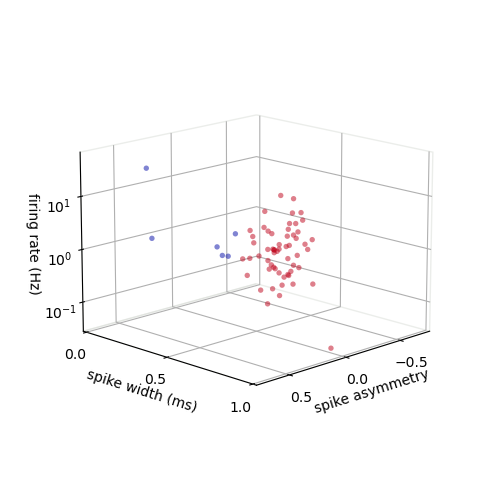

In [15]:
''' plot the waveform properties '''
fig = plt.figure(figsize=(8, 4))
ax = plt.axes([0, 0, .6, 1.2], projection='3d')

n_excite = np.sum(clu1_idx)
print(f'{n_excite}/{n_cells} cells are putative excitatory neurons ({np.round((n_excite/n_cells)*100, 1)}%)')

# all excitatory cells
ax.scatter(asymm[clu1_idx],
           width[clu1_idx],
           log_fr[clu1_idx],
           c='xkcd:scarlet',
           alpha=0.5, lw=0, s=15, zorder=0)

# all inhibitory cells
ax.scatter(asymm[clu2_idx],
           width[clu2_idx],
           log_fr[clu2_idx],
           c='xkcd:cobalt blue', 
           alpha=0.5, lw=0, s=15, zorder=0)

# labels
ax.set_xlabel('spike asymmetry')
ax.set_ylabel('spike width (ms)')
ax.set_zlabel('firing rate (Hz)')

# log scale the z-axis
ax.zaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.zaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# limits
ax.set_xlim([-0.75, 0.75])
ax.set_xticks([-0.5, 0, 0.5])
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])

# background color
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('xkcd:grey')
ax.yaxis.pane.set_edgecolor('xkcd:grey')
ax.zaxis.pane.set_edgecolor('xkcd:grey')
ax.xaxis.pane.set_color('xkcd:light grey')
ax.yaxis.pane.set_color('xkcd:light grey')
ax.zaxis.pane.set_color('xkcd:light grey')

ax.view_init(azim=45, elev=15)
ax.set_box_aspect(aspect=None, zoom=0.8)
plt.show()

# fig.savefig(f'{save_folder}waveform_props.png', 
#                   dpi=600, bbox_inches='tight')

In [16]:
''' load and format the annotated seed struct '''
seed_struct = loadmat_sbx(f'{data_dir}{annotated_seed_file}')['annotatedSeeds']
count_data = seed_struct['countData']
print(seed_struct.keys())
print(count_data.keys())

Z:/Isabel/data/hpc_implants/SLV132/SLV132_250326/behavior_data/annotatedSeeds.mat
dict_keys(['countData', 'bk_height_seedDetect', 'smSeedWindow', 'gainThresh', 'loseThresh', 'minLoseDur', 'validFrames', 'seedIntTol', 'path', 'beakPos', 'smSeed', 'cacheLoc', 'seedTimes', 'nEvents', 'newCacheTimes', 'endCacheTimes', 'cacheNum', 'fromCache_site', 'fromCache_event', 'toCache_site', 'toCache_event', 'gainMat', 'loseMat', 'initImgs', 'preIms', 'postIms', 'flagInt', 'seedChanges', 'initSeedCounts', 'prePreds', 'postPreds'])
dict_keys(['newPerch', 'endPerch', 'perchNum', 'newSite', 'endSite', 'siteNum', 'newFeeder', 'endFeeder', 'feederNum', 'newWater', 'endWater', 'waterNum', 'newBeakPerch', 'endBeakPerch', 'beakPerchNum', 'params'])


In [17]:
''' classify caches/retrievals/checks '''
# data params
all_int_start = count_data['newSite']
all_int_end = count_data['endSite']
all_int_changes = np.sum(seed_struct['seedChanges'], axis=1)
n_interactions = all_int_start.shape[0]

# caches = add a seed
cache_onsets = all_int_start[all_int_changes > 0]
cache_offsets = all_int_end[all_int_changes > 0]
caches = all_int_changes.copy()
caches[all_int_changes < 0] = 0

# retrievals = subtract a seed
retrieval_onsets = all_int_start[all_int_changes < 0]
retrieval_offsets = all_int_end[all_int_changes < 0]
retrievals = all_int_changes.copy()
retrievals[all_int_changes > 0] = 0

# checks = no change
check_onsets = all_int_start[all_int_changes == 0]
check_offsets = all_int_end[all_int_changes == 0]
checks = all_int_changes==0

In [18]:
''' classify feeding bouts and visits '''
# get all perch interactions
all_perch_start = count_data['newPerch']
all_perch_end = count_data['endPerch']
all_perch_idx = count_data['perchNum']
n_perches = all_perch_start.shape[0]

# eating bouts
eat_onsets = count_data['newBeakPerch']
eat_offsets = count_data['endBeakPerch']
all_non_visit_start = np.append(eat_onsets, all_int_start)

# exclude perches with eating and site interactions
visits = np.full(n_perches, 1).astype(bool)
for i, (ps, pe) in enumerate(zip(all_perch_start, all_perch_end)):
    start_idx = all_non_visit_start > ps
    end_idx = all_non_visit_start < pe
    if any(start_idx & end_idx):
        visits[i] = False        
visit_onsets = all_perch_start[visits]
visit_offsets = all_perch_end[visits]

In [19]:
''' classify feeder interactions - beak near feeder '''
# get all feeder interactions
all_feeder_start = count_data['newFeeder']
all_feeder_end = count_data['endFeeder']
all_feeder_idx = count_data['feederNum']
n_feeder_int = all_feeder_start.shape[0]

# classify each interaction as open vs. closed
feeder_open_frames = feeder_open*60*50
feeder_close_frames = feeder_close*60*50
feeder_status = np.full(n_feeder_int, 0)
for i, (fs, fe) in enumerate(zip(all_feeder_start, all_feeder_end)):
    start_status = 0
    end_status = 0
    for fo, fc in zip(feeder_open_frames, feeder_close_frames):
        if (fs > fo) & (fs < fc):
            start_status = 1
        if (fe > fo) & (fe < fc):
            end_status = 1
    feeder_status[i] = np.mean((start_status, end_status))

In [20]:
''' classify feeder interactions - feet on feeder perch '''
# get all feeder interactions
all_feeder_start = []
all_feeder_end = []
all_feeder_idx = []
n_feeder_int = 0
feeder_perches = np.asarray([84, 85, 86, 87])
for i, (ps, pe) in enumerate(zip(all_perch_start, all_perch_end)):
    this_perch = all_perch_idx[i]
    if this_perch in feeder_perches:
        all_feeder_start.append(ps)
        all_feeder_end.append(pe)
        all_feeder_idx.append(np.where(feeder_perches==this_perch)[0][0] + 1)
        n_feeder_int += 1
all_feeder_start = np.asarray(all_feeder_start)
all_feeder_end = np.asarray(all_feeder_end)
all_feeder_idx = np.asarray(all_feeder_idx)
        
# classify each interaction as open vs. closed
feeder_open_frames = feeder_open*60*50
feeder_close_frames = feeder_close*60*50
feeder_status = np.full(n_feeder_int, 0)
for i, (fs, fe) in enumerate(zip(all_feeder_start, all_feeder_end)):
    start_status = 0
    end_status = 0
    for fo, fc in zip(feeder_open_frames, feeder_close_frames):
        if (fs > fo) & (fs < fc):
            start_status = 1
        if (fe > fo) & (fe < fc):
            end_status = 1
    feeder_status[i] = np.mean((start_status, end_status))

In [21]:
''' load the frame times '''
framet_raw = np.load(f'{data_dir}frame_times.npy')
framet_raw = np.squeeze(framet_raw)
dt = np.unique(np.round(np.diff(framet_raw), 4))
if dt.shape[0] > 1:
    print(f'warning irregular frame times!\nframe dt = {dt}')
else:
    dt = dt[0]
    
assert seed_struct['validFrames'].shape[0] == framet_raw.shape[0]

In [22]:
# align so that 0 is the video start time
start_t = framet_raw[0]
frame_t = framet_raw - start_t
spike_t = spike_samp_raw - start_t*sampling_rate
frame_samples = np.append(frame_t, frame_t[-1] + dt)*sampling_rate

# keep only spikes from within the session
spike_id = spike_id[(spike_t >= 0) & (spike_t <= frame_samples[-1])]
spike_t = spike_t[(spike_t >= 0) & (spike_t <= frame_samples[-1])]

n_frames = frame_t.shape[0]

In [23]:
''' spikes per frame and spike bool '''
spike_fr = np.zeros((n_cells, n_frames))
i = -1
for c_idx, cell in enumerate(good_clusters):
    i += 1
    spk_times = spike_t[spike_id==cell]       
    spike_fr[i], _ = np.histogram(spk_times, frame_samples)
spike_bool = spike_fr.astype(bool)

### relationship between neural firing and feeders - single cells
- feeder onset/offset based on beak entry into feeder zone (as defined in seed struct)
- feeder onset/offset based on feet on feeder perch

In [24]:
'''
raster aligned to feeder interaction offset sorted by:
- open vs. closed
- feeder location
- interaction duration
'''
# time window
feeder_t_window = 20 # seconds
feeder_t_points = np.arange(-feeder_t_window//2, feeder_t_window//2 + dt, dt)
n_t_pts = feeder_t_points.shape[0]
fr_halfwidth = n_t_pts//2

# divide by open vs closed (currently excluding partial feeder open interactions)
open_feeder_onsets = all_feeder_start[feeder_status==1]
open_feeder_offsets = all_feeder_end[feeder_status==1]
open_feeder_idx = all_feeder_idx[feeder_status==1]
n_open_feeder = open_feeder_onsets.shape[0]

closed_feeder_onsets = all_feeder_start[feeder_status==0]
closed_feeder_offsets = all_feeder_end[feeder_status==0]
closed_feeder_idx = all_feeder_idx[feeder_status==0]
n_closed_feeder = closed_feeder_onsets.shape[0]

# matrix of spike times by feeder interactions
feeder_off_mat = np.zeros((n_cells, n_feeder_int, n_t_pts), dtype=bool)
feeder_ids = np.unique(all_feeder_idx)
sorted_feeder_ons = np.zeros(n_feeder_int)
feeder_switch_pts = np.asarray([])
for c_idx in range(n_cells):
    spk_times = spike_bool[c_idx]
    
    # open feeders sorted by feeder location + duration
    f_idx = 0
    for f in feeder_ids:
        if any(open_feeder_idx==f):
            f_on = open_feeder_onsets[open_feeder_idx==f]
            f_off = open_feeder_offsets[open_feeder_idx==f]
            f_duration = f_off - f_on
            duration_idx = np.argsort(f_duration)
            for i, dur_idx in enumerate(duration_idx):
                sort_idx = i + f_idx
                start_idx = (f_off[dur_idx] - fr_halfwidth).astype(int)
                end_idx = (f_off[dur_idx] + fr_halfwidth + 1).astype(int) 
                if f_off[dur_idx] - fr_halfwidth < 0:
                    n_t = spk_times[:end_idx].shape[0]
                    feeder_off_mat[c_idx, sort_idx, -n_t:] = spk_times[:end_idx]
                elif f_off[dur_idx] + fr_halfwidth >= n_frames:
                    n_t = spk_times[start_idx:].shape[0]
                    feeder_off_mat[c_idx, sort_idx, :n_t] = spk_times[start_idx:]
                else:
                    feeder_off_mat[c_idx, sort_idx] = spk_times[start_idx:end_idx]
                if c_idx == 0:
                    sorted_feeder_ons[sort_idx] = np.max((-f_duration[dur_idx], -fr_halfwidth))
            f_idx += f_on.shape[0]
            if c_idx == 0:
                feeder_switch_pts = np.append(feeder_switch_pts, f_idx)
    
    # closed feeders sorted by feeder location + duration
    f_idx = n_open_feeder
    for f in feeder_ids:
        if any(closed_feeder_idx==f):
            f_on = closed_feeder_onsets[closed_feeder_idx==f]
            f_off = closed_feeder_offsets[closed_feeder_idx==f]
            f_duration = f_off - f_on
            duration_idx = np.argsort(f_duration)
            for i, dur_idx in enumerate(duration_idx):
                sort_idx = i + f_idx
                start_idx = (f_off[dur_idx] - fr_halfwidth).astype(int)
                end_idx = (f_off[dur_idx] + fr_halfwidth + 1).astype(int) 
                if f_off[dur_idx] - fr_halfwidth < 0:
                    n_t = spk_times[:end_idx].shape[0]
                    feeder_off_mat[c_idx, sort_idx, -n_t:] = spk_times[:end_idx]
                elif f_off[dur_idx] + fr_halfwidth >= n_frames:
                    n_t = spk_times[start_idx:].shape[0]
                    feeder_off_mat[c_idx, sort_idx, :n_t] = spk_times[start_idx:]
                else:
                    feeder_off_mat[c_idx, sort_idx] = spk_times[start_idx:end_idx]
                
                # save onset times
                if c_idx == 0:
                    sorted_feeder_ons[sort_idx] = np.max((-f_duration[dur_idx], -fr_halfwidth))
            
            # save switch points
            f_idx += f_on.shape[0]
            if c_idx == 0:
                feeder_switch_pts = np.append(feeder_switch_pts, f_idx)
        
    
                
feeder_switch_pts = feeder_switch_pts[:-1].astype(int)

In [25]:
print(f'closed feeder IDs: {np.unique(closed_feeder_idx)}')
print(f'open feeder IDs: {np.unique(open_feeder_idx)}')

closed feeder IDs: [1 2 3 4]
open feeder IDs: [1 2 3 4]


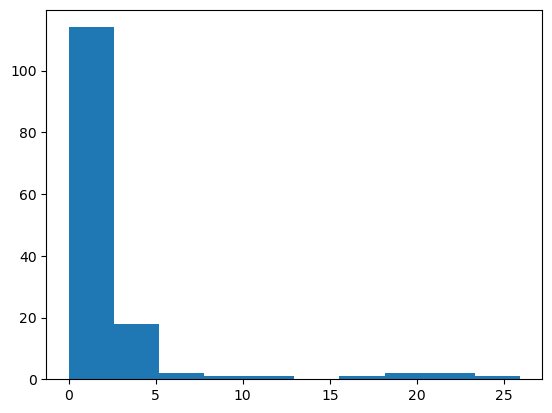

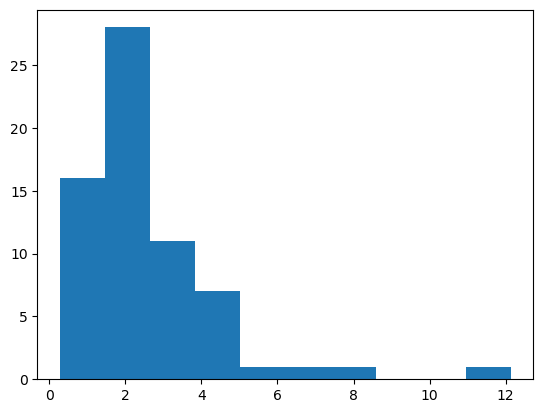

In [26]:
plt.hist((closed_feeder_offsets - closed_feeder_onsets)/50)
plt.show()
plt.hist((open_feeder_offsets - open_feeder_onsets)/50)
plt.show()

In [27]:
''' compute the psth aligned to onset and offset '''
# aligned to onsets
t_on_start = -2 # time relative to interaction onset in seconds
t_on_end = 1
timepoints_on = np.arange(t_on_start, t_on_end, dt)
n_t_on = timepoints_on.shape[0]
fr_on_start = t_on_start//dt
fr_on_end = t_on_end//dt

feeder_onset_spikes = np.full((n_cells, n_feeder_int, n_t_on), np.nan)
for c_idx in range(n_cells):
    cell_fr = spike_fr[c_idx]
    
    # open feeders sorted by feeder location + duration
    f_idx = 0
    for f in feeder_ids:
        if any(open_feeder_idx==f):
            f_on = open_feeder_onsets[open_feeder_idx==f]
            f_off = open_feeder_offsets[open_feeder_idx==f]
            f_duration = f_off - f_on
            duration_idx = np.argsort(f_duration)
            for i, dur_idx in enumerate(duration_idx):
                sort_idx = i + f_idx
                start_idx = (f_on[dur_idx] + fr_on_start).astype(int)
                end_idx = (f_on[dur_idx] + fr_on_end + 1).astype(int) 
                if end_idx > f_off[dur_idx]:
                    end_idx = f_off[dur_idx]
                    n_bins = end_idx - start_idx
                    feeder_onset_spikes[c_idx, sort_idx, :n_bins] = cell_fr[start_idx:end_idx]
                else:
                    feeder_onset_spikes[c_idx, sort_idx] = cell_fr[start_idx:end_idx]
            f_idx += f_on.shape[0]
    
    # closed feeders sorted by feeder location + duration
    f_idx = n_open_feeder
    for f in feeder_ids:
        if any(closed_feeder_idx==f):
            f_on = closed_feeder_onsets[closed_feeder_idx==f]
            f_off = closed_feeder_offsets[closed_feeder_idx==f]
            f_duration = f_off - f_on
            duration_idx = np.argsort(f_duration)
            for i, dur_idx in enumerate(duration_idx):
                sort_idx = i + f_idx
                start_idx = (f_on[dur_idx] + fr_on_start).astype(int)
                end_idx = (f_on[dur_idx] + fr_on_end + 1).astype(int) 
                if end_idx > f_off[dur_idx]:
                    end_idx = f_off[dur_idx]
                    n_bins = end_idx - start_idx
                    feeder_onset_spikes[c_idx, sort_idx, :n_bins] = cell_fr[start_idx:end_idx]
                else:
                    feeder_onset_spikes[c_idx, sort_idx] = cell_fr[start_idx:end_idx]
            f_idx += f_on.shape[0]

In [28]:
# aligned to offsets
t_off_start = -1
t_off_end = 2
timepoints_off = np.arange(t_off_start, t_off_end, dt)
n_t_off = timepoints_off.shape[0]
fr_off_start = t_off_start//dt
fr_off_end = t_off_end//dt
total_frames = spike_fr.shape[1]

feeder_offset_spikes = np.full((n_cells, n_feeder_int, n_t_on), np.nan)
for c_idx in range(n_cells):
    cell_fr = spike_fr[c_idx]
    
    # open feeders sorted by feeder location + duration
    f_idx = 0
    for f in feeder_ids:
        if any(open_feeder_idx==f):
            f_on = open_feeder_onsets[open_feeder_idx==f]
            f_off = open_feeder_offsets[open_feeder_idx==f]
            f_duration = f_off - f_on
            duration_idx = np.argsort(f_duration)
            for i, dur_idx in enumerate(duration_idx):
                sort_idx = i + f_idx
                start_idx = (f_off[dur_idx] + fr_off_start).astype(int)
                end_idx = (f_off[dur_idx] + fr_off_end + 1).astype(int)
                if start_idx < 0:
                    start_idx = 0
                    n_bins = end_idx - start_idx
                    feeder_offset_spikes[c_idx, sort_idx, -n_bins:] = cell_fr[start_idx:end_idx]
                elif end_idx >= total_frames:
                    end_idx = -1
                    n_bins = total_frames - start_idx
                    feeder_offset_spikes[c_idx, sort_idx, -n_bins:] = cell_fr[start_idx:end_idx]
                elif start_idx < f_on[dur_idx]:
                    start_idx = f_on[dur_idx]
                    n_bins = end_idx - start_idx
                    feeder_offset_spikes[c_idx, sort_idx, -n_bins:] = cell_fr[start_idx:end_idx]
                else:
                    feeder_offset_spikes[c_idx, sort_idx] = cell_fr[start_idx:end_idx]
            f_idx += f_on.shape[0]
    
    # closed feeders sorted by feeder location + duration
    f_idx = n_open_feeder
    for f in feeder_ids:
        if any(closed_feeder_idx==f):
            f_on = closed_feeder_onsets[closed_feeder_idx==f]
            f_off = closed_feeder_offsets[closed_feeder_idx==f]
            f_duration = f_off - f_on
            duration_idx = np.argsort(f_duration)
            for i, dur_idx in enumerate(duration_idx):
                sort_idx = i + f_idx
                start_idx = (f_off[dur_idx] + fr_off_start).astype(int)
                end_idx = (f_off[dur_idx] + fr_off_end + 1).astype(int) 
                if start_idx < 0:
                    start_idx = 0
                    n_bins = end_idx - start_idx
                    feeder_offset_spikes[c_idx, sort_idx, -n_bins:] = cell_fr[start_idx:end_idx]
                elif end_idx >= total_frames:
                    end_idx = -1
                    n_bins = total_frames - start_idx - 1
                    feeder_offset_spikes[c_idx, sort_idx, -n_bins:] = cell_fr[start_idx:end_idx]
                elif start_idx < f_on[dur_idx]:
                    start_idx = f_on[dur_idx]
                    n_bins = end_idx - start_idx
                    feeder_offset_spikes[c_idx, sort_idx, -n_bins:] = cell_fr[start_idx:end_idx]
                else:
                    feeder_offset_spikes[c_idx, sort_idx] = cell_fr[start_idx:end_idx]
            f_idx += f_on.shape[0]

In [29]:
# compute the psth for each feeder state
n_feeder_states = np.unique(closed_feeder_idx).shape[0] + np.unique(open_feeder_idx).shape[0]
feeder_onset_psth = np.zeros((n_cells, n_feeder_states, n_t_on))
feeder_offset_psth = np.zeros((n_cells, n_feeder_states, n_t_off))
feeder_onset_sem = np.zeros((n_cells, n_feeder_states, n_t_on))
feeder_offset_sem = np.zeros((n_cells, n_feeder_states, n_t_off))

start_idx = 0
n_visits = np.diff(np.append(np.append(0, feeder_switch_pts), n_feeder_int))
print(f'n visits {n_visits}')
for i, end_idx in enumerate(np.append(feeder_switch_pts, np.asarray([-1]))):
    feeder_onset_psth[:, i] = np.nanmean(feeder_onset_spikes[:, start_idx:end_idx], axis=1)//dt
    feeder_offset_psth[:, i] = np.nanmean(feeder_offset_spikes[:, start_idx:end_idx], axis=1)//dt    
    
#     if n_visits[i] > 5:
#         feeder_onset_sem[:, i] = stats.sem(feeder_onset_spikes[:, start_idx:end_idx]//dt, axis=1, nan_policy='omit')
#         feeder_offset_sem[:, i] = stats.sem(feeder_onset_spikes[:, start_idx:end_idx]//dt, axis=1, nan_policy='omit')//dt
    start_idx = end_idx

n visits [33 11 10 12 24 25 76 17]


In [30]:
# smoothed firing rates and SEM
feeder_onset_psth_smooth = gaussian_filter1d(feeder_onset_psth, 5, axis=2, mode='nearest')
feeder_offset_psth_smooth = gaussian_filter1d(feeder_offset_psth, 5, axis=2, mode='nearest')
# feeder_onset_sem_smooth = gaussian_filter1d(feeder_onset_sem, 5, axis=2, mode='nearest')
# feeder_offset_sem_smooth = gaussian_filter1d(feeder_offset_sem, 5, axis=2, mode='nearest')

In [ ]:
''' feeder responses
250328 (128 total cells, ~22% feeder responsive):
    18 up during: 15, 36, 51, 63, 92, 213, 244, 257, 258, 298, 314, 318, 405, 409, 442, 470, 541, 543
    7 up after: 37, 134, 192, 218, 425, 462, 491
    3 other: 399, 456, 478    
    cell 134 is a projection cell
    
250326 (64 total cells, ~28% feeder responsive):
    12 up during: 2, 14, 137, 144, 255, 304, 350, 353, 358, 362, 392, 408
    3 up after: 71, 356, 360
    3 other (off during? on before/during/after? other things?): 1, 164, 322
    cells 71, 255 are projection cells
'''

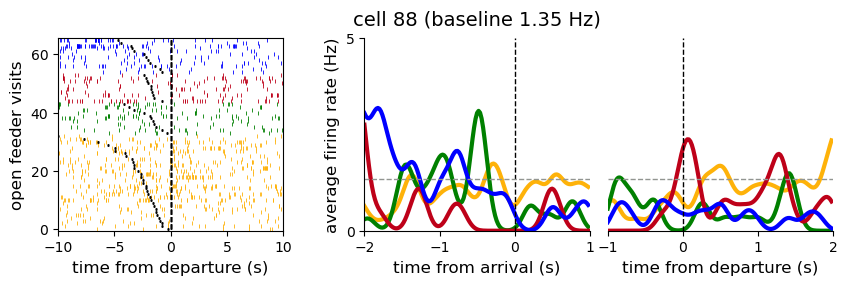

In [31]:
''' plot open only:
rasters (separated by open/ closed and sorted by feeder ID + duration)
tuning curves
'''
# fig params
feeder_colors = ['xkcd:saffron', 'green', 'xkcd:scarlet', 'blue', 'k', 
                 'xkcd:saffron', 'green', 'xkcd:scarlet', 'blue']
spk_s = 6
psth_lw = 3
on_lw = 1
off_lw = 1
on_s = 3
time_int = 5

# data params
n_open_ids = np.unique(open_feeder_idx).shape[0]
avg_firing_rate = waveform_struct['meanRate']
avg_fr_session = np.round(avg_firing_rate, 2)
n_open_int = feeder_switch_pts[n_open_ids-1]

ex_cells = np.asarray([88])
for cell_id in ex_cells:
    c_idx = np.where(good_clusters==cell_id)[0][0]
    ch = wf_ch_idx[c_idx]
    f, ax = plt.subplots(1, 4, figsize=(10, 2.5),
                         gridspec_kw=dict(width_ratios=[1, 0.2, 1, 1], wspace=0.1))
    
    # remove extraneous tick labels and axes
    for j in range(2):
        ax[j+2].spines['top'].set_visible(False)
        ax[j+2].spines['right'].set_visible(False)
    ax[3].spines['left'].set_visible(False)
    ax[3].tick_params(labelleft=False)
    
    # hide the spacer subplot
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['left'].set_visible(False)
    ax[1].spines['bottom'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    ax[1].set_facecolor('None')
    
    # rasters aligned to feeder offsets
    color_idx = 0
    for feeder_idx in range(n_open_int):
        if feeder_idx in feeder_switch_pts:
            color_idx += 1
        spk_idx_on = feeder_off_mat[c_idx, feeder_idx]
        spk_t_on = feeder_t_points[spk_idx_on]
        ax[0].scatter(spk_t_on, np.full(spk_t_on.shape[0], feeder_idx),
                         color=feeder_colors[color_idx], marker='|',
                         lw=0.6, s=spk_s, alpha=1)
    
    # cycle through feeder IDs
    start_idx = 0
    for state_idx, end_idx in enumerate(feeder_switch_pts[:n_open_ids]):            
        # psth aligned to onsets and offsets
        if n_visits[state_idx] < 5:
            print(f'excluding feeder {state_idx+1} from PSTH (too few trials)')
        else:
            ax[2].plot(timepoints_on, feeder_onset_psth_smooth[c_idx, state_idx], 
                       lw=psth_lw, color=feeder_colors[state_idx])
            ax[3].plot(timepoints_off, feeder_offset_psth_smooth[c_idx, state_idx],
                       lw=psth_lw, color=feeder_colors[state_idx])
    
        # label onsets and offsets for the rasters        
        ax[0].vlines(0, 0, n_open_int, colors='k', linestyles='dashed', lw=off_lw)
        sub_ons = sorted_feeder_ons[:n_open_int]
        ax[0].scatter(sub_ons/50, np.arange(n_open_int), color='k', marker='|',
                      lw=on_lw, s=on_s, zorder=2)
        start_idx = end_idx
                   
    # label onset and offset, baseline FR for the psth
#     max_on = np.ceil(np.nanmax(feeder_onset_psth_smooth[c_idx][[0, 2, 3]]))
#     max_off = np.ceil(np.nanmax(feeder_offset_psth_smooth[c_idx][[0, 2, 3]]))
    max_on = np.ceil(np.nanmax(feeder_onset_psth_smooth[c_idx]))
    max_off = np.ceil(np.nanmax(feeder_offset_psth_smooth[c_idx]))
    max_all = np.max([max_on, max_off])
    ax[2].vlines(0, 0, max_all, colors='k', linestyles='dashed', lw=off_lw)
    ax[3].vlines(0, 0, max_all, colors='k', linestyles='dashed', lw=off_lw)
    ax[2].hlines(avg_fr_session[c_idx], t_on_start, t_on_end, 
                 colors='xkcd:gray', linestyles='dashed', lw=off_lw)
    ax[3].hlines(avg_fr_session[c_idx], t_off_start, t_off_end, 
                 colors='xkcd:gray', linestyles='dashed', lw=off_lw)

    # limits and ticks
    ax[0].set_xlim(feeder_t_points[0], feeder_t_points[-1])
    ax[0].set_ylim(-0.5, n_open_int-0.5)
    ax[0].set_xticks(np.arange(-feeder_t_window//2, feeder_t_window//2 + 0.5, time_int))
#     ax[0].set_yticks(np.arange(0, n_feeder_int, 5))

    ax[2].set_xlim(t_on_start, t_on_end)
    ax[3].set_xlim(t_off_start, t_off_end)
    ax[2].set_ylim(0, max_all)
    ax[2].set_yticks([0, max_all])
    ax[3].set_ylim(0, max_all)
    ax[3].set_yticks([])

    # axis labels
    ax[2].set_title(f'cell {cell_id} (baseline {avg_fr_session[c_idx]} Hz)',
                    fontsize=title_size, pad=10)
    ax[0].set_xlabel('time from departure (s)', fontsize=axis_label)
    ax[2].set_xlabel('time from arrival (s)', fontsize=axis_label)
    ax[3].set_xlabel('time from departure (s)', fontsize=axis_label)
    ax[2].set_ylabel('average firing rate (Hz)', fontsize=axis_label)
    ax[0].set_ylabel('open feeder visits', fontsize=axis_label)
                     
    plt.show()
    f.savefig(f'{save_subfolder}/open_feeders_cell{cell_id}.png', dpi=400, bbox_inches='tight')

### Other behavioral variables

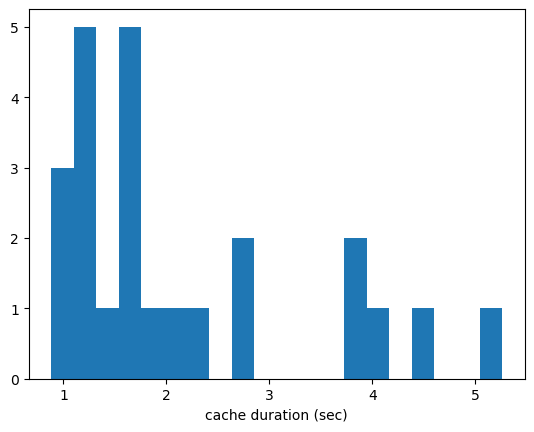

In [32]:
''' spikes aligned to cache offset '''
''' get spikes by cache - sort by duration '''
# params
n_cache = cache_offsets.shape[0]
cache_window = 20 # seconds
cache_t_points = np.arange(-cache_window//2, cache_window//2 + dt, dt)
n_t_pts = cache_t_points.shape[0]
fr_halfwidth = n_t_pts//2

# sort caches by duration
cache_dur = cache_offsets - cache_onsets
plt.hist(cache_dur/50, bins=20)
plt.xlabel('cache duration (sec)')
plt.show()
duration_idx = np.argsort(cache_dur)

# matrix of spike times by cache
cache_off_mat = np.zeros((n_cells, n_cache, n_t_pts), dtype=bool)
for c_idx in range(n_cells):
    spk_times = spike_bool[c_idx]
    for i, cache_idx in enumerate(duration_idx):  
        start_idx = (cache_offsets[cache_idx] - fr_halfwidth).astype(int)
        end_idx = (cache_offsets[cache_idx] + fr_halfwidth + 1).astype(int)
        cache_off_mat[c_idx, i] = spk_times[start_idx:end_idx]
        
# psth cache on/off aligned
avg_fr_cache_off = np.mean(cache_off_mat, axis=1)//dt

In [33]:
''' for plotting '''
t_zero_idx = (cache_window//2//dt + 1).astype(int)
cache_ons = cache_t_points[t_zero_idx - cache_dur[duration_idx]]
cache_offs = cache_t_points[t_zero_idx + cache_dur[duration_idx]]
cache_pts = np.arange(n_cache)

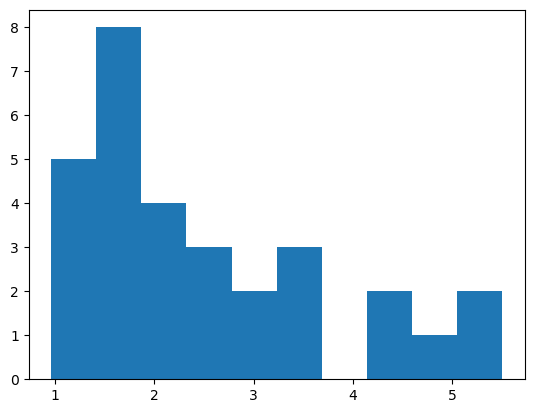

In [34]:
''' spikes aligned to retrieval offset '''
''' get spikes by retrieval - sort by duration '''
# params
n_retrieve = retrieval_offsets.shape[0]
ret_window = 20 # seconds
ret_t_points = np.arange(-ret_window//2, ret_window//2 + dt, dt)
n_t_pts = ret_t_points.shape[0]
fr_halfwidth = n_t_pts//2
t_zero_idx = (ret_window//2//dt + 1).astype(int)

# sort retrievals by duration
retrieval_dur = retrieval_offsets - retrieval_onsets
plt.hist(retrieval_dur/50)
plt.show()
duration_idx = np.argsort(retrieval_dur)

# matrix of spike times by retrieval
ret_off_mat = np.zeros((n_cells, n_retrieve, n_t_pts), dtype=bool)
for c_idx in range(n_cells):
    spk_times = spike_bool[c_idx]
    for i, ret_idx in enumerate(duration_idx):          
        # offsets
        start_idx = (retrieval_offsets[ret_idx] - fr_halfwidth).astype(int)
        end_idx = (retrieval_offsets[ret_idx] + fr_halfwidth + 1).astype(int)
        if retrieval_offsets[ret_idx] - fr_halfwidth < 0:
            n_t = spk_times[:end_idx].shape[0]
            ret_off_mat[c_idx, i, -n_t:] = spk_times[:end_idx]
        elif retrieval_offsets[ret_idx] + fr_halfwidth >= n_frames:
            n_t = spk_times[start_idx:].shape[0]
            ret_off_mat[c_idx, i, :n_t] = spk_times[start_idx:]
        else:
            ret_off_mat[c_idx, i] = spk_times[start_idx:end_idx]
            
# psth retrieval on/off aligned
avg_fr_ret_off = np.mean(ret_off_mat, axis=1)//dt

In [35]:
''' for plotting '''
sorted_durations = retrieval_dur[duration_idx]
ret_short_dur = sorted_durations[sorted_durations <= fr_halfwidth]
n_ret_short = ret_short_dur.shape[0]
ret_ons = ret_t_points[t_zero_idx - ret_short_dur]
ret_offs = ret_t_points[t_zero_idx + ret_short_dur]

In [36]:
n_visits

array([33, 11, 10, 12, 24, 25, 76, 17])

C:\Users\ilow1\AppData\Local\Temp\ipykernel_3636\2011662759.py:29: RuntimeWarning: invalid value encountered in divide
  perch_fr = perch_spikes / (perch_time*dt)


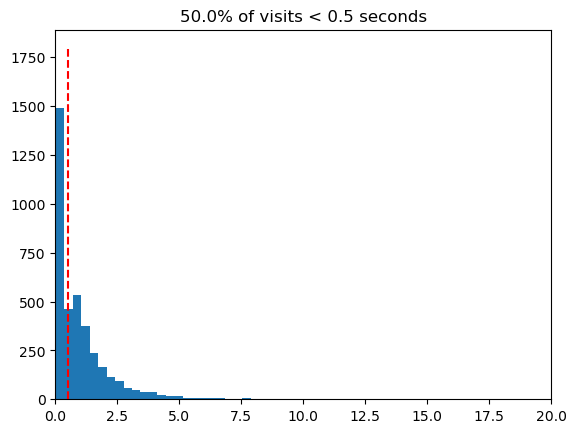

In [37]:
''' place coding 
method 1: visits during movement bouts
avg firing rate for each perch for visits < min time
'''
# define short duration visits by thresholding
visit_durations = visit_offsets - visit_onsets
n_perch_visits = visit_onsets.shape[0]
visit_thresh = 0.5 # seconds
perch_site = count_data['perchNum']

# firing rate by perch for quick visits
quick_visits = np.full(n_perches, 0).astype(bool)
n_perch_sites = np.max(perch_site) + 1
perch_spikes = np.zeros((n_cells, n_perch_sites))
perch_time = np.zeros(n_perch_sites)
visit_idx = -1
for n_perch, ps in enumerate(all_perch_start):
    if visits[n_perch]:
        perch_idx = perch_site[n_perch]
        visit_idx += 1
        v_on = visit_onsets[visit_idx]
        v_off = visit_offsets[visit_idx]
        v_dur = v_off - v_on
        if v_dur*dt <= visit_thresh:
            quick_visits[n_perch] = True
            n_spk = np.sum(spike_fr[:, v_on:v_off], axis=1)
            perch_spikes[:, perch_idx] += n_spk
            perch_time[perch_idx] += v_dur
perch_fr = perch_spikes / (perch_time*dt)

# plot to check
pct_quick_visits = np.round(np.sum(quick_visits) / n_perch_visits, 1)*100
plt.hist(visit_durations*dt, bins=500)
plt.vlines(visit_thresh, 0, 1800, color='r', linestyle='dashed')
plt.xlim([0, 20])
plt.title(f'{pct_quick_visits}% of visits < {visit_thresh} seconds')
plt.show()

In [38]:
''' load the arena model image and object data '''
# arena_img = mpimg.imread(arena_folder + image_file)
arena_data = loadmat(f'{arena_dir}{arena_items_file}', squeeze_me=True)
arena_data["perches"] = arena_data["perch_w_site"]
arena_data["feeder_perches"] = arena_data["perch_no_site"]

In [ ]:
''' feeder responses
250328 (128 total cells, ~22% feeder responsive):
    18 up during: 15, 36, 51, 63, 92, 213, 244, 257, 258, 298, 314, 318, 405, 409, 442, 470, 541, 543
    7 up after: 37, 134, 192, 218, 425, 462, 491
    3 other: 399, 456, 478    
    cell 134 is a projection cell
    
250326 (64 total cells, ~28% feeder responsive):
    12 up during: 2, 14, 137, 144, 255, 304, 350, 353, 358, 362, 392, 408
    3 up after: 71, 356, 360
    3 other (off during? on before/during/after? other things?): 1, 164, 322
    cells 71, 255 are projection cells
'''

C:\Users\ilow1\AppData\Local\Temp\ipykernel_3636\1670209304.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('viridis')


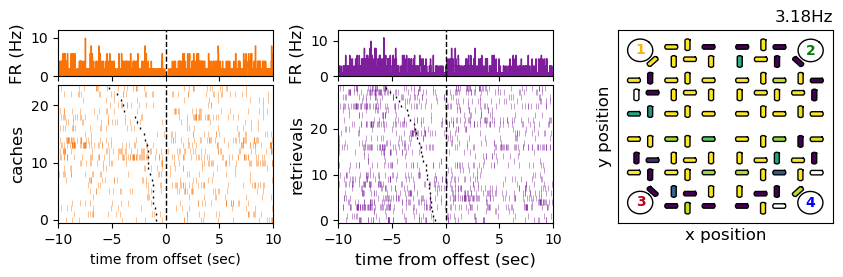

In [39]:
''' plot caches, retrievals, place coding '''
# fig params
cache_color = 'xkcd:orange'
ret_color = 'xkcd:purple'
cmap = get_cmap('viridis')
feeder_colors = ['xkcd:saffron', 'green', 'xkcd:scarlet', 'blue']

spk_s = 15
psth_lw = 2
on_lw = 1
off_lw = 1
on_s = 3
time_int = 5

# data params
avg_firing_rate = waveform_struct['meanRate']
avg_fr_session = np.round(avg_firing_rate, 2)

ex_cells = np.asarray([88])
for cell_id in ex_cells:
    c_idx = np.where(good_clusters==cell_id)[0][0]
    ch = wf_ch_idx[c_idx]
    
    f = plt.figure(figsize=(10, 2.5))
    gs = f.add_gridspec(2, 3, height_ratios=[1, 3], hspace=0.1,
                        width_ratios=[1, 1, 1], wspace=0.3)
    ax00 = f.add_subplot(gs[0, 0])
    ax10 = f.add_subplot(gs[1, 0])
    ax01 = f.add_subplot(gs[0, 1])
    ax11 = f.add_subplot(gs[1, 1])
    ax2 = f.add_subplot(gs[:, 2])
    
    ''' caches '''
    # plot the average firing rate aligned to offset
    ax00.fill_between(cache_t_points, avg_fr_cache_off[c_idx],
                          step="mid", color=cache_color)

    # plot raster aligned to cache offsets
    for cache_idx in range(n_cache):
        spk_idx_off = cache_off_mat[c_idx, cache_idx]
        spk_t_off = cache_t_points[spk_idx_off]
        ax10.scatter(spk_t_off, np.full(spk_t_off.shape[0], cache_idx),
                         color=cache_color, marker='|',
                         lw=0.6, s=spk_s, alpha=.5, zorder=1)

    # label onsets and offsets
    max_cache_fr = np.max(avg_fr_cache_off[c_idx])
    ax00.vlines(0, 0, max_cache_fr+2, colors='k', linestyles='dashed',
                    lw=off_lw, zorder=2)
    ax10.vlines(0, 0, n_cache, colors='k', linestyles='dashed',
                    lw=off_lw, zorder=2)
    ax10.scatter(cache_ons, np.arange(n_cache), color='k', marker='|',
                     lw=on_lw, s=on_s, zorder=2)

    # limits and labels
    ax10.set_xlim(cache_t_points[0], cache_t_points[-1])
    ax10.set_ylim(-0.5, n_cache - 0.5)
    ax00.set_xlim(cache_t_points[0], cache_t_points[-1])
    ax00.set_ylim(0, max_cache_fr+2)

    ax10.set_xticks(np.arange(-cache_window//2, cache_window//2 + 2, time_int))
    ax00.set_xticks(np.arange(-cache_window//2, cache_window//2 + 2, time_int))
    ax00.tick_params(labelbottom=False)

#     ax00.set_title('caches')
    ax10.set_xlabel('time from offset (sec)')
    ax10.set_ylabel('caches', fontsize=axis_label)
    ax00.set_ylabel('FR (Hz)', fontsize=axis_label)

    ''' b. retrievals '''
    # plot the average firing rate aligned to offset
    ax01.fill_between(ret_t_points, avg_fr_ret_off[c_idx],
                          step="mid", color=ret_color)

    #plot raster aligned to retrieval offsets
    for ret_idx in range(n_retrieve):
        spk_idx_off = ret_off_mat[c_idx, ret_idx]
        spk_t_off = ret_t_points[spk_idx_off]
        ax11.scatter(spk_t_off, np.full(spk_t_off.shape[0], ret_idx),
                         color=ret_color, marker='|',
                         lw=0.6, s=spk_s, alpha=.5, zorder=1)

    # label onsets and offsets
    max_ret_fr = np.max(avg_fr_ret_off[c_idx])
    ax01.vlines(0, 0, max_ret_fr+2, colors='k', linestyles='dashed',
                    lw=off_lw, zorder=2)
    ax11.vlines(0, 0, n_retrieve, colors='k', linestyles='dashed',
                    lw=off_lw)
    ax11.scatter(ret_ons, np.arange(n_ret_short), color='k', marker='|',
                     lw=on_lw, s=on_s, zorder=2)

    # limits and labels
    ax11.set_xlim(ret_t_points[0], ret_t_points[-1])
    ax11.set_ylim(-0.5, n_retrieve - 0.5)
    ax01.set_xlim(ret_t_points[0], ret_t_points[-1])
    ax01.set_ylim(0, max_ret_fr+2)

    ax11.set_xticks(np.arange(-ret_window//2, ret_window//2 + 2, time_int))
    ax01.set_xticks(np.arange(-ret_window//2, ret_window//2 + 2, time_int))
    ax01.tick_params(labelbottom=False)

#     ax01. set_title('retrievals')
    ax11.set_xlabel('time from offest (sec)', fontsize=axis_label)
    ax11.set_ylabel('retrievals', fontsize=axis_label)
    ax01.set_ylabel('FR (Hz)', fontsize=axis_label)
    
    
    ''' f. place coding '''
    # get the colormap for this cell
    this_fr = perch_fr[c_idx]
    spk_colors = cmap(this_fr)
    max_fr = np.round(np.nanpercentile(this_fr, 95), 2)
    
    # plot the perches
    i = -1
    for n in range(n_perch_sites):
        if n < n_perch_sites - 4:
            convex_hull = arena_data["perches"][n]["ConvexHull"]
        else:
            i += 1
            convex_hull = arena_data["feeder_perches"][i]["ConvexHull"]
        ax2.plot(convex_hull[:, 1], convex_hull[:, 0], c='k', lw=1)
        ax2.fill_betweenx(convex_hull[:, 0], convex_hull[:, 1], 
                         ec='none', fc=spk_colors[n])

    # plot the feeders
    for i in range(4):
        convex_hull = arena_data["feeders"][i]["ConvexHull"]
        ax2.plot(convex_hull[:, 1], convex_hull[:, 0],
                      c='k', lw=1)
#         ax[1, 2].scatter(np.mean(convex_hull[:, 1]), np.mean(convex_hull[:, 0]),
#                           marker='o', s=75, lw=0.5, ec=feeder_colors[i], fc='w', alpha=1, zorder=1)
        ax2.text(np.mean(convex_hull[:, 1]), np.mean(convex_hull[:, 0]),
                 f'{i+1}', size=10, weight='bold', color=feeder_colors[i],
                 ha='center', va='center', zorder=2)
    
    # limits and labels
    ax2.set_title(f'{max_fr}Hz', loc='right', fontsize=axis_label)
    ax2.set_ylim(ax2.get_ylim()[::-1])
    ax2.set_xlim(ax2.get_xlim()[::-1])
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xlabel('x position', fontsize=axis_label)
    ax2.set_ylabel('y position', fontsize=axis_label)
    
    
    plt.show()
    f.savefig(f'{save_subfolder}/other_behavior_cell{cell_id}.png', dpi=400, bbox_inches='tight')    

In [249]:
feeder_on_mat.shape

(128, 44, 1001)

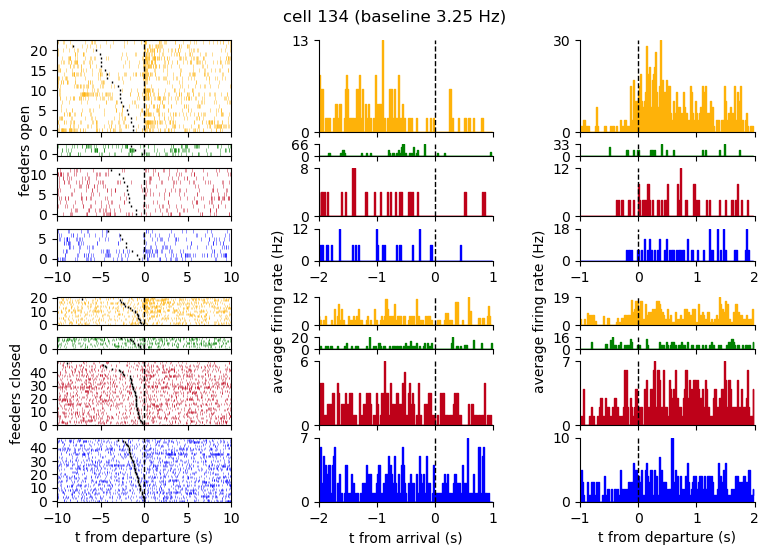

In [218]:
''' plot:
rasters (separated by open/ closed and sorted by feeder ID + duration)
tuning curves
'''
# fig params
feeder_colors = ['xkcd:saffron', 'green', 'xkcd:scarlet', 'blue', 'k', 
                 'xkcd:saffron', 'green', 'xkcd:scarlet', 'blue']
on_lw = 1
off_lw = 1
on_s = 4
spk_s = 9
spk_s_off = 3
time_int = 5
n_open_ids = np.unique(open_feeder_idx).shape[0]
h_ratios = np.insert(n_visits, n_open_ids, 3)
h_ratios[n_open_ids+1:] = h_ratios[n_open_ids+1:]/3

avg_firing_rate = waveform_struct['meanRate']
avg_fr_session = np.round(avg_firing_rate, 2)

ex_cells = np.asarray([134])
for cell_id in ex_cells:
    c_idx = np.where(good_clusters==cell_id)[0][0]
    ch = wf_ch_idx[c_idx]
    f, ax = plt.subplots(n_feeder_states+1, 3, figsize=(9, 6),
                         gridspec_kw=dict(height_ratios=h_ratios,
                                          width_ratios=[1, 1, 1],
                                          hspace=0.3, wspace=0.5))
    
    # hide the spacer subplots
    for i in range(3):
        ax[n_open_ids, i].spines['top'].set_visible(False)
        ax[n_open_ids, i].spines['left'].set_visible(False)
        ax[n_open_ids, i].spines['bottom'].set_visible(False)
        ax[n_open_ids, i].spines['right'].set_visible(False)
        ax[n_open_ids, i].set_xticks([])
        ax[n_open_ids, i].set_yticks([])
        ax[n_open_ids, i].set_facecolor('None')
    
    # remove extraneous tick labels and axes
    for i in range(n_feeder_states+1):
        for j in range(2):
            ax[i, j+1].spines['top'].set_visible(False)
            ax[i, j+1].spines['right'].set_visible(False) 
        if (i == n_open_ids-1) | (i == n_feeder_states):
            continue
        for j in range(3):
            ax[i, j].tick_params(labelbottom=False)
    
    # x-axis labels + title
    ax[-1, 0].set_xlabel('t from departure (s)')
    ax[-1, 1].set_xlabel('t from arrival (s)')
    ax[-1, 2].set_xlabel('t from departure (s)')
    f.suptitle(f'cell {cell_id} (baseline {avg_fr_session[c_idx]} Hz)', y=0.93)
    
    start_idx = 0
    for state_idx, end_idx in enumerate(np.append(feeder_switch_pts, np.asarray([n_feeder_int]))):
        psth_idx = state_idx
        if state_idx >= n_open_ids:
            state_idx = state_idx + 1
        sub_mat = feeder_off_mat[c_idx, start_idx:end_idx]
        n_ints = end_idx - start_idx
        
        # rasters aligned to feeder offsets
        for i in range(n_ints):
            spk_idx_on = sub_mat[i]
            spk_t_on = feeder_t_points[spk_idx_on]
            if state_idx <= n_open_ids:
                ax[state_idx, 0].scatter(spk_t_on, np.full(spk_t_on.shape[0], i),
                                         color=feeder_colors[state_idx], marker='|',
                                         lw=0.6, s=spk_s, alpha=.5)
            else:
                ax[state_idx, 0].scatter(spk_t_on, np.full(spk_t_on.shape[0], i),
                                         color=feeder_colors[state_idx], marker='|',
                                         lw=0.6, s=spk_s_off, alpha=.5)
            
        # psth aligned to onsets and offsets
        ax[state_idx, 1].fill_between(timepoints_on, feeder_onset_psth[c_idx][psth_idx],
                                      step="mid", color=feeder_colors[state_idx])
        ax[state_idx, 2].fill_between(timepoints_off, feeder_offset_psth[c_idx][psth_idx],
                                      step="mid", color=feeder_colors[state_idx])
    
        # label onset and offset
        max_on = np.nanmax(feeder_onset_psth[c_idx][psth_idx])
        max_off = np.nanmax(feeder_offset_psth[c_idx][psth_idx])
        ax[state_idx, 0].vlines(0, 0, n_ints,
                                colors='k', linestyles='dashed', lw=off_lw)
        ax[state_idx, 1].vlines(0, 0, max_on,
                                colors='k', linestyles='dashed', lw=off_lw)
        ax[state_idx, 2].vlines(0, 0, max_off,
                                colors='k', linestyles='dashed', lw=off_lw)
        sub_ons = sorted_feeder_ons[start_idx:end_idx]
        ax[state_idx, 0].scatter(sub_ons/50, np.arange(n_ints), color='k', marker='|',
                                 lw=on_lw, s=on_s, zorder=2)
                
        # limits and ticks
        ax[state_idx, 0].set_xlim(feeder_t_points[0], feeder_t_points[-1])
        ax[state_idx, 0].set_ylim(-0.5, n_ints-0.5)
        ax[state_idx, 0].set_xticks(np.arange(-feeder_t_window//2, feeder_t_window//2 + 0.5, time_int))
        if state_idx <= n_open_ids:
            ax[state_idx, 0].set_yticks(np.arange(0, n_ints, 5))
        else:
            ax[state_idx, 0].set_yticks(np.arange(0, n_ints, 10))
        
        ax[state_idx, 1].set_xlim(t_on_start, t_on_end)
        ax[state_idx, 2].set_xlim(t_off_start, t_off_end)
#         ax[state_idx, 1].set_xticks(np.arange(t_on_start, t_on_end+0.1, 0.5))
#         ax[state_idx, 1].set_xticks(np.arange(t_off_start, t_off_end+0.1, 0.5))
        ax[state_idx, 1].set_ylim(0, max_on)
        ax[state_idx, 1].set_yticks([0, max_on])
        ax[state_idx, 2].set_ylim(0, max_off)
        ax[state_idx, 2].set_yticks([0, max_off])
        
        # axis labels
        if state_idx == 5:
            ax[state_idx, 1].set_ylabel('average firing rate (Hz)')
            ax[state_idx, 2].set_ylabel('average firing rate (Hz)')
        if state_idx == 1:
            ax[state_idx, 0].set_ylabel('feeders open')
        if state_idx == 7:
            ax[state_idx, 0].set_ylabel('feeders closed')
            
        start_idx = end_idx
                
plt.show()
f.savefig(f'{save_folder}/feeder_responses_cell{cell_id}.png', dpi=400, bbox_inches='tight')

### Feeder responses all cells
- firing relative to feeder visits
    - use ratio of firing rate before departure vs. after to sort
    - try taking a window from 1 sec to 250ms before, 250ms to 1 sec after
    - choose each cell's preferred feeder (peak fr)
- firing rates before and after feeders open?